In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygeohash as pgh

In [5]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')


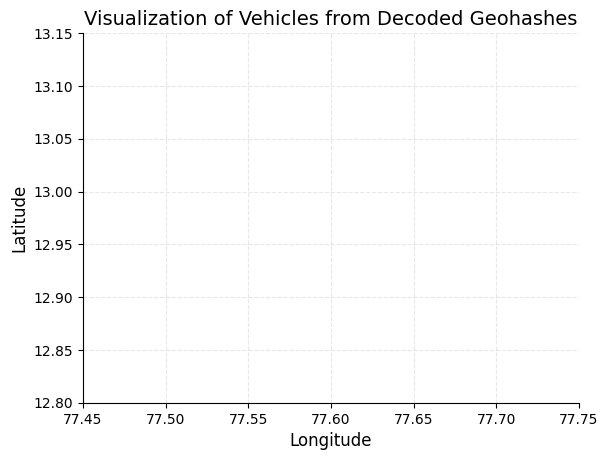

In [ ]:
#Converting Geohash to coordinates
def decode_geohash(gh):
    try:
        return pgh.decode(gh)
    except Exception:
        # Handle invalid geohashes gracefully
        return (None, None)

df_train[['latitude', 'longitude']] = df_train['geohash'].apply(
    lambda x: pd.Series(decode_geohash(x))
)
df_test[['latitude', 'longitude']] = df_test['geohash'].apply(
    lambda x: pd.Series(decode_geohash(x))
)

df_train.head()

plt.figure(figsize=(10, 8))
plt.scatter(
    df_train['longitude'], 
    df_train['latitude'], 
    color='purple', 
    marker='.', 
    s=30, 
    alpha=0.7
)

# Plot formatting
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title(f'Geohash Locations from train.csv ({len(locations_df)} unique areas)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Clean up visual borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)